# Visualizations of loss Function

In [2]:
import sys
import os
main_dir = os.path.dirname(os.getcwd())
sys.path.append(main_dir)

import argparse
import os
import time

import numpy as np

from MambaCD.changedetection.configs.config import get_config

import torch
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from MambaCD.changedetection.datasets.make_data_loader import SemanticChangeDetectionDatset, make_data_loader
from MambaCD.changedetection.utils_func.metrics import Evaluator
from MambaCD.changedetection.models.STMambaSCD import STMambaSCD
import MambaCD.changedetection.utils_func.lovasz_loss as L
from torch.optim.lr_scheduler import StepLR

from MambaCD.changedetection.utils_func.mcd_utils import accuracy, SCDD_eval_all, AverageMeter
import matplotlib.pyplot as plt

/home/e19063/ChangeDetection-Buddhi/MambaCD/classification/models/utils.py:157: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)
/home/e19063/ChangeDetection-Buddhi/MambaCD/classification/models/utils.py:190: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_bwd


In [3]:
torch.cuda.set_device(1)

In [ ]:
MODEL_PATH = os.path.join(
    main_dir, "MambaCD/saved_models/SECOND/MambaSCD_1739387348.1310859attention_newVssm/21000_model.pth"
)

In [5]:
configs_path = os.path.join(main_dir, 'MambaCD/changedetection/configs/vssm1/vssm_small_224.yaml')
model_path = os.path.join(main_dir, 'MambaCD/saved_models')

SECOND_DATASET_PATH = os.path.join(main_dir, 'Datasets', 'SECOND')
SECOND_TRAIN_DATASET_PATH = os.path.join(SECOND_DATASET_PATH, 'train')
SECOND_TEST_DATASET_PATH = os.path.join(SECOND_DATASET_PATH, 'test')
SECOND_TRAIN_DATA_LIST_PATH = os.path.join(SECOND_DATASET_PATH, 'train.txt')
SECOND_TEST_DATA_LIST_PATH = os.path.join(SECOND_DATASET_PATH, 'test.txt')

train_data_list = []
with open(SECOND_TRAIN_DATA_LIST_PATH, 'r') as f:
    for line in f:
        train_data_list.append(line.strip())

test_data_list = []
with open(SECOND_TEST_DATA_LIST_PATH, 'r') as f:
    for line in f:
        test_data_list.append(line.strip())

class ARGS:
    def __init__(self):
        self.cfg = configs_path
        self.opts = None
        self.pretrained_weight_path = MODEL_PATH
        self.dataset = 'SECOND'
        self.type = 'train'
        self.train_dataset_path = SECOND_TRAIN_DATASET_PATH
        self.train_data_list_path = SECOND_TRAIN_DATA_LIST_PATH
        self.test_dataset_path = SECOND_TEST_DATASET_PATH
        self.test_data_list_path = SECOND_TEST_DATA_LIST_PATH
        self.shuffle = False
        self.batch_size = 1
        self.crop_size = 256
        self.train_data_name_list = train_data_list
        self.test_data_name_list = test_data_list
        self.start_iter = 0
        self.cuda = True
        self.max_iters = 400000
        self.model_type = 'MambaSCD'
        self.model_param_path = model_path
        self.resume = None
        self.learning_rate = 1e-4
        self.momentum = 0.9
        self.weight_decay = 5e-4

args = ARGS()

In [6]:
args = args
config = get_config(args)

train_data_loader = make_data_loader(args)

deep_model = STMambaSCD(
    output_cd = 2, 
    output_clf = 7,
    pretrained=args.pretrained_weight_path,
    patch_size=config.MODEL.VSSM.PATCH_SIZE, 
    in_chans=config.MODEL.VSSM.IN_CHANS, 
    num_classes=config.MODEL.NUM_CLASSES, 
    depths=config.MODEL.VSSM.DEPTHS, 
    dims=config.MODEL.VSSM.EMBED_DIM, 
    # ===================
    ssm_d_state=config.MODEL.VSSM.SSM_D_STATE,
    ssm_ratio=config.MODEL.VSSM.SSM_RATIO,
    ssm_rank_ratio=config.MODEL.VSSM.SSM_RANK_RATIO,
    ssm_dt_rank=("auto" if config.MODEL.VSSM.SSM_DT_RANK == "auto" else int(config.MODEL.VSSM.SSM_DT_RANK)),
    ssm_act_layer=config.MODEL.VSSM.SSM_ACT_LAYER,
    ssm_conv=config.MODEL.VSSM.SSM_CONV,
    ssm_conv_bias=config.MODEL.VSSM.SSM_CONV_BIAS,
    ssm_drop_rate=config.MODEL.VSSM.SSM_DROP_RATE,
    ssm_init=config.MODEL.VSSM.SSM_INIT,
    forward_type=config.MODEL.VSSM.SSM_FORWARDTYPE,
    # ===================
    mlp_ratio=config.MODEL.VSSM.MLP_RATIO,
    mlp_act_layer=config.MODEL.VSSM.MLP_ACT_LAYER,
    mlp_drop_rate=config.MODEL.VSSM.MLP_DROP_RATE,
    # ===================
    drop_path_rate=config.MODEL.DROP_PATH_RATE,
    patch_norm=config.MODEL.VSSM.PATCH_NORM,
    norm_layer=config.MODEL.VSSM.NORM_LAYER,
    downsample_version=config.MODEL.VSSM.DOWNSAMPLE,
    patchembed_version=config.MODEL.VSSM.PATCHEMBED,
    gmlp=config.MODEL.VSSM.GMLP,
    use_checkpoint=config.TRAIN.USE_CHECKPOINT,
    ) 

deep_model.load_state_dict(torch.load(MODEL_PATH))
deep_model.cuda()

=> merge config from /home/e19063/ChangeDetection-Buddhi/MambaCD/changedetection/configs/vssm1/vssm_small_224.yaml


/home/e19063/ChangeDetection-Buddhi/MambaCD/changedetection/models/Mamba_backbone.py:33: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  _ckpt = torch.load(open(ckpt, "rb"), m

Successfully load ckpt /home/e19063/ChangeDetection-Buddhi/MambaCD/saved_models/SECOND/MambaSCD_1739384271.942201ss/500_model.pth
Failed loading checkpoint form /home/e19063/ChangeDetection-Buddhi/MambaCD/saved_models/SECOND/MambaSCD_1739384271.942201ss/500_model.pth: 'model'
False


/tmp/ipykernel_393231/3711684686.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  deep_model.load_state_dict(torch.load(MODEL_PATH))


STMambaSCD(
  (encoder): Backbone_VSSM(
    (patch_embed): Sequential(
      (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): Permute()
      (2): LayerNorm((48,), eps=1e-05, elementwise_affine=True)
      (3): Permute()
      (4): GELU(approximate='none')
      (5): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (6): Permute()
      (7): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (layers): ModuleList(
      (0): Sequential(
        (blocks): Sequential(
          (0): VSSBlock(
            (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
            (op): SS2D(
              (out_norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
              (in_proj): Linear(in_features=96, out_features=384, bias=False)
              (act): SiLU()
              (conv2d): Conv2d(192, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=192, bias=False)
              (out_proj): Linear(in_feat

# Image Lib

In [7]:
ori_label_value_dict = {
    'background': (0, 0, 0),
    'low_vegetation': (0, 128, 0),
    'nvg_surface': (128, 128, 128),
    'tree': (0, 255, 0),
    'water': (0, 0, 255),
    'Building': (128, 0, 0),
    'Playground': (255, 0, 0)
}

target_label_value_dict = {
    'background': 0,
    'low_vegetation': 1,
    'nvg_surface': 2,
    'tree': 3,
    'water': 4,
    'Building': 5,
    'Playground': 6
}

def map_labels_to_colors(labels, ori_label_value_dict, target_label_value_dict):
    # Reverse the target_label_value_dict to get a mapping from target labels to original labels
    target_to_ori = {v: k for k, v in target_label_value_dict.items()}
    
    # Initialize an empty 3D array for the color-mapped labels
    H, W = labels.shape
    color_mapped_labels = np.zeros((H, W, 3), dtype=np.uint8)
    
    for target_label, ori_label in target_to_ori.items():
        # Find where the label matches the current target label
        mask = labels == target_label
        
        # Map these locations to the corresponding color value
        color_mapped_labels[mask] = ori_label_value_dict[ori_label]
    
    return color_mapped_labels

  0%|          | 0/400000 [00:00<?, ?it/s]

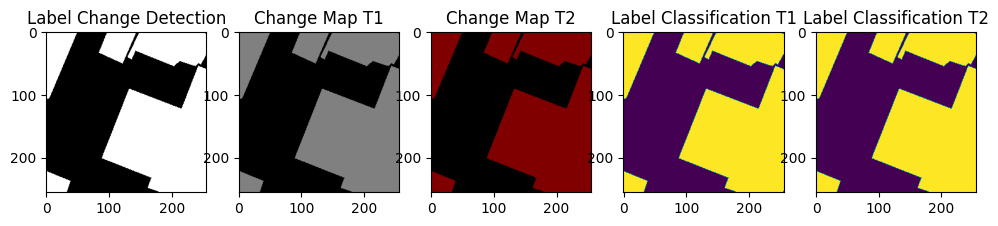

  0%|          | 0/400000 [00:00<?, ?it/s]


In [8]:
elem_num = len(train_data_loader)
train_enumerator = enumerate(train_data_loader)
for _ in tqdm(range(elem_num)):
    itera, data = train_enumerator.__next__()
    pre_change_imgs, post_change_imgs, label_cd, label_clf_t1, label_clf_t2, _ = data

    pre_change_imgs = pre_change_imgs.cuda()
    post_change_imgs = post_change_imgs.cuda()
    label_cd = label_cd.cuda().long()
    label_clf_t1 = label_clf_t1.cuda().long()
    label_clf_t2 = label_clf_t2.cuda().long()

    change_map_T1 = map_labels_to_colors(np.squeeze(label_clf_t1.cpu().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)
    change_map_T2 = map_labels_to_colors(np.squeeze(label_clf_t2.cpu().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)

    fig1, axes = plt.subplots(1, 5, figsize=(12, 4))
    axes[0].imshow(label_cd[0].cpu().numpy(), cmap='gray')
    axes[0].set_title('Label Change Detection')
    axes[1].imshow(change_map_T1)
    axes[1].set_title('Change Map T1')
    axes[2].imshow(change_map_T2)
    axes[2].set_title('Change Map T2')
    axes[3].imshow(label_clf_t1[0].cpu().numpy())
    axes[3].set_title('Label Classification T1')
    axes[4].imshow(label_clf_t2[0].cpu().numpy())
    axes[4].set_title('Label Classification T2')
    plt.show()
    break

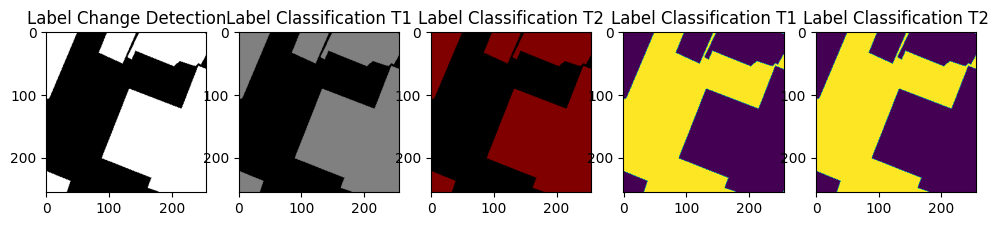

In [9]:
label_clf_t1[label_clf_t1 == 0] = 255
label_clf_t2[label_clf_t2 == 0] = 255

change_map_T1 = map_labels_to_colors(np.squeeze(label_clf_t1.cpu().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)
change_map_T2 = map_labels_to_colors(np.squeeze(label_clf_t2.cpu().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)

fig1, axes = plt.subplots(1, 5, figsize=(12, 4))
axes[0].imshow(label_cd[0].cpu().numpy(), cmap='gray')
axes[0].set_title('Label Change Detection')
axes[1].imshow(change_map_T1)
axes[1].set_title('Label Classification T1')
axes[2].imshow(change_map_T2)
axes[2].set_title('Label Classification T2')
axes[3].imshow(label_clf_t1[0].cpu().numpy())
axes[3].set_title('Label Classification T1')
axes[4].imshow(label_clf_t2[0].cpu().numpy())
axes[4].set_title('Label Classification T2')
plt.show()

In [10]:
output_1, output_semantic_t1_, output_semantic_t2_ = deep_model(pre_change_imgs, post_change_imgs)

In [11]:
output_semantic_t1 = output_semantic_t1_.clone()
output_semantic_t2 = output_semantic_t2_.clone()

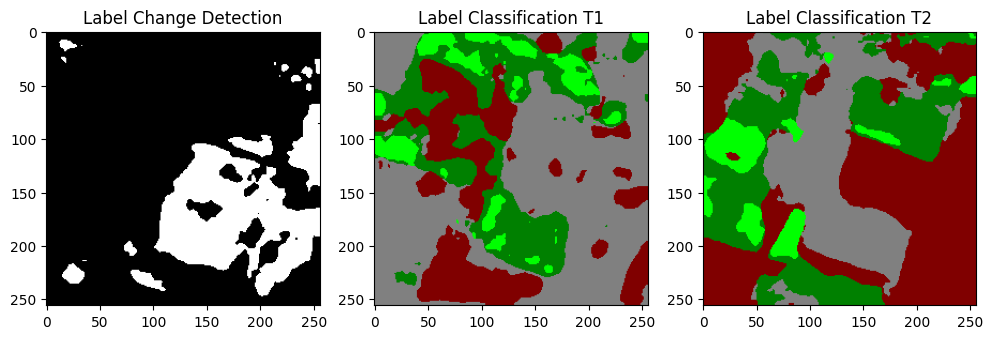

In [12]:
label_out_cd = output_1.clone()
label_out_cd = torch.argmax(label_out_cd, dim=1)

label_out_clf_t1 = output_semantic_t1.clone()
label_out_clf_t1 = torch.argmax(label_out_clf_t1, dim=1)

label_out_clf_t2 = output_semantic_t2.clone()
label_out_clf_t2 = torch.argmax(label_out_clf_t2, dim=1)


label_out_clf_t1 = map_labels_to_colors(np.squeeze(label_out_clf_t1.cpu().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)
label_out_clf_t2 = map_labels_to_colors(np.squeeze(label_out_clf_t2.cpu().numpy()), ori_label_value_dict=ori_label_value_dict, target_label_value_dict=target_label_value_dict)

fig1, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(label_out_cd[0].cpu().numpy(), cmap='gray')
axes[0].set_title('Label Change Detection')
axes[1].imshow(label_out_clf_t1)
axes[1].set_title('Label Classification T1')
axes[2].imshow(label_out_clf_t2)
axes[2].set_title('Label Classification T2')
plt.show()

# Loss

In [13]:
from ChangeDetection.CDlib.loss import ce2_dice1, ce2_dice1_multiclass, contrastive_loss,dice_loss_multiclass

In [14]:
pre_change_imgs = pre_change_imgs.float()
post_change_imgs = post_change_imgs.float()

ce2_dice_loss_cd = ce2_dice1(output_1, label_cd)
ce2_dice_loss_clf_t1 = ce2_dice1_multiclass(output_semantic_t1, label_clf_t1)
ce2_dice_loss_clf_t2 = ce2_dice1_multiclass(output_semantic_t2, label_clf_t2)

print(f"CE2-Dice Loss CD: {ce2_dice_loss_cd}\n")
print(f"CE2-Dice Loss CLF T1: {ce2_dice_loss_clf_t1}\n")
print(f"CE2-Dice Loss CLF T2: {ce2_dice_loss_clf_t2}\n")

lovasz_loss_cd = L.lovasz_softmax(F.softmax(output_1, dim=1), label_cd, ignore=255)
lovasz_loss_clf_t1 = L.lovasz_softmax(F.softmax(output_semantic_t1, dim=1), label_clf_t1, ignore=255)
lovasz_loss_clf_t2 = L.lovasz_softmax(F.softmax(output_semantic_t2, dim=1), label_clf_t2, ignore=255)

print(f"Lovasz Loss CD: {lovasz_loss_cd}\n")
print(f"Lovasz Loss CLF T1: {lovasz_loss_clf_t1}\n")
print(f"Lovasz Loss CLF T2: {lovasz_loss_clf_t2}\n")

change_mask = (label_cd == 0).float()
contrastive_loss_ = contrastive_loss(output_semantic_t1, output_semantic_t2, change_mask)
print(f"Contrastive Loss: {contrastive_loss_}")

CE2-Dice Loss CD: 0.8553964495658875

CE2-Dice Loss CLF T1: 1.531531810760498

CE2-Dice Loss CLF T2: 1.1565912961959839

Lovasz Loss CD: 0.5117639899253845

Lovasz Loss CLF T1: 0.5711820125579834

Lovasz Loss CLF T2: 0.46192604303359985

Contrastive Loss: 0.11608737707138062


# 500
CE2-Dice Loss CD: 0.9210820198059082

CE2-Dice Loss CLF T1: 1.6630609035491943

CE2-Dice Loss CLF T2: 1.4475862979888916

Lovasz Loss CD: 0.5729653835296631

Lovasz Loss CLF T1: 0.6302815079689026

Lovasz Loss CLF T2: 0.5870606899261475

Contrastive Loss: 0.03091038018465042